# Регрессия по функциональным данным через линейные функционалы

В этой лабораторной работе рассматривается задача регрессии, где входной объект является не конечным набором признаков, а функцией $x(t)$, заданной на интервале $[0, 1]$. Цель состоит в том, чтобы преобразовать каждую функцию в конечный вектор признаков с помощью линейных интегральных функционалов и затем построить линейную регрессионную модель.

Для функции $x(t)$ и весовой функции $\varphi_k(t)$ признак задаётся как скалярное произведение в пространстве $L^2[0,1]$:

$$
z_{ik} = \langle x_i, \varphi_k \rangle =
\int_0^1 x_i(t)\varphi_k(t)\,dt.
$$

После вычисления признаков модель принимает вид

$$
\widehat y_i = \beta_0 + \sum_{k=1}^{m}\beta_k z_{ik}.
$$

Также модель можно интерпретировать через весовую функцию

$$
w(t) = \sum_{k=1}^{m}\beta_k\varphi_k(t),
$$

поскольку

$$
\widehat y(x) = \beta_0 + \langle x, w\rangle.
$$

Основная цель экспериментов — сравнить разные системы функционалов, исследовать влияние числа функционалов, регуляризации, шума и плотности сетки.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

RANDOM_STATE = 42
TEST_SIZE = 0.25

np.random.seed(RANDOM_STATE)

## 2. Задание сетки на интервале $[0,1]$

Функции в вычислениях хранятся как значения на равномерной сетке

$$
t_1, t_2, \dots, t_p.
$$

Чем больше точек сетки, тем точнее численное приближение интегралов.

In [3]:
a, b = 0.0, 1.0
n_grid = 200

t = np.linspace(a, b, n_grid)

print(f"Интервал: [{a}, {b}]")
print(f"Количество точек сетки: {n_grid}")
print(f"Шаг сетки примерно: {t[1] - t[0]:.5f}")

Интервал: [0.0, 1.0]
Количество точек сетки: 200
Шаг сетки примерно: 0.00503


## 3. Генерация синтетических функциональных данных

Основной синтетический датасет задаётся формулой

$$
x_i(t)=a_i\sin(2\pi t)+b_i\cos(2\pi t)+c_it+\varepsilon_i(t),
$$

где $a_i$, $b_i$, $c_i$ — случайные коэффициенты, а $\varepsilon_i(t)$ — шум в функции.

Целевой ответ задаётся через истинную весовую функцию

$$
w_{\text{true}}(t)=2\sin(2\pi t)-t.
$$

Тогда

$$
y_i = \int_0^1 x_i(t)w_{\text{true}}(t)\,dt + \eta_i,
$$

где $\eta_i$ — шум в ответе.

Такой способ генерации удобен тем, что истинная зависимость известна заранее, поэтому можно оценивать не только качество прогноза, но и восстановление функции $w(t)$.

In [4]:
def true_weight_function(t):
    """Истинная весовая функция, через которую генерируется ответ y."""
    return 2.0 * np.sin(2.0 * np.pi * t) - t


def generate_smooth_functional_data(
    n_samples=500,
    n_grid=200,
    sigma_x=0.10,
    sigma_y=0.10,
    random_state=42,
):
    """
    Генерирует синтетические функциональные данные.

    x_i(t) = a_i sin(2πt) + b_i cos(2πt) + c_i t + eps_i(t)
    y_i = ∫ x_i(t) w_true(t) dt + eta_i
    """
    rng = np.random.default_rng(random_state)
    t = np.linspace(0.0, 1.0, n_grid)

    a_coef = rng.normal(0.0, 1.0, size=n_samples)
    b_coef = rng.normal(0.0, 1.0, size=n_samples)
    c_coef = rng.normal(0.0, 1.0, size=n_samples)

    signal = (
        a_coef[:, None] * np.sin(2.0 * np.pi * t)[None, :]
        + b_coef[:, None] * np.cos(2.0 * np.pi * t)[None, :]
        + c_coef[:, None] * t[None, :]
    )

    noise_x = rng.normal(0.0, sigma_x, size=(n_samples, n_grid))
    X_func = signal + noise_x

    w_true = true_weight_function(t)
    y_clean = np.trapz(X_func * w_true[None, :], t, axis=1)
    y = y_clean + rng.normal(0.0, sigma_y, size=n_samples)

    params = pd.DataFrame({
        "a": a_coef,
        "b": b_coef,
        "c": c_coef,
        "y_clean": y_clean,
        "y": y,
    })

    return t, X_func, y, y_clean, w_true, params

In [5]:
n_samples = 500
sigma_x = 0.10
sigma_y = 0.10

t, X_func, y, y_clean, w_true, params = generate_smooth_functional_data(
    n_samples=n_samples,
    n_grid=n_grid,
    sigma_x=sigma_x,
    sigma_y=sigma_y,
    random_state=RANDOM_STATE,
)

print("Размер матрицы функций X_func:", X_func.shape)
print("Размер вектора ответов y:", y.shape)

params.head()

Размер матрицы функций X_func: (500, 200)
Размер вектора ответов y: (500,)


/var/folders/qq/yzyzzd593z575k6v21b7crw40000gp/T/ipykernel_36350/1137088402.py:36: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  y_clean = np.trapz(X_func * w_true[None, :], t, axis=1)


,a,b,c,y_clean,y
0,0.304717,1.363862,-0.059283,0.385182,0.226472
1,-1.039984,0.895185,-0.729287,-0.725415,-0.657422
2,0.750451,-0.719480,-0.414473,1.126743,0.993299
3,0.940565,-1.502503,0.633910,0.689355,0.659703
4,-1.951035,-2.964529,0.002993,-2.245702,-2.296858


## 4. Визуализация примеров функций

Построим несколько сгенерированных функций $x_i(t)$, чтобы увидеть, с какими объектами работает модель.

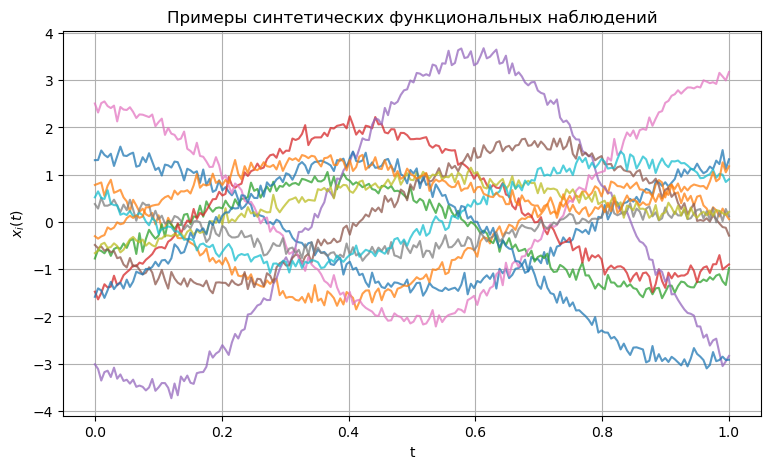

In [6]:
plt.figure(figsize=(9, 5))

for i in range(12):
    plt.plot(t, X_func[i], alpha=0.75)

plt.xlabel("t")
plt.ylabel(r"$x_i(t)$")
plt.title("Примеры синтетических функциональных наблюдений")
plt.grid(True)
plt.show()

## 5. Истинная весовая функция $w_{\text{true}}(t)$

Так как данные синтетические, настоящая функция, через которую формируется ответ, известна:

$$
w_{\text{true}}(t)=2\sin(2\pi t)-t.
$$

В дальнейшем будем сравнивать с ней восстановленную моделью функцию $\widehat w(t)$.

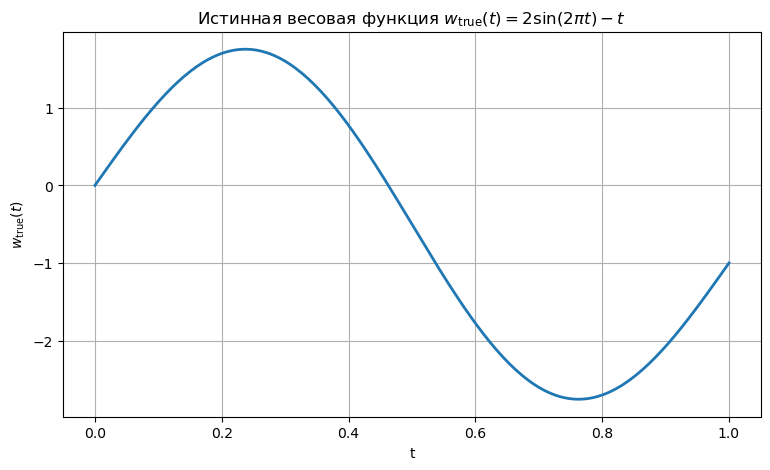

In [7]:
plt.figure(figsize=(9, 5))

plt.plot(t, w_true, linewidth=2)
plt.xlabel("t")
plt.ylabel(r"$w_{\mathrm{true}}(t)$")
plt.title(r"Истинная весовая функция $w_{\mathrm{true}}(t)=2\sin(2\pi t)-t$")
plt.grid(True)
plt.show()

## 6. Численное интегрирование и скалярное произведение

Скалярное произведение функций приближается методом трапеций:

$$
\langle f,g\rangle = \int_0^1 f(t)g(t)\,dt
\approx \mathrm{trapz}(f(t_j)g(t_j)).
$$

На основе этого вычисляется матрица признаков $Z$, где

$$
Z_{ik} = \langle x_i, \varphi_k\rangle.
$$


In [8]:
def inner_product(f, g, t):
    """Численное скалярное произведение двух функций на сетке t."""
    return np.trapz(f * g, t)


def compute_feature_matrix(X_func, basis, t):
    """
    Вычисляет матрицу признаков Z.

    X_func: массив формы (n_samples, n_grid)
    basis: массив формы (m, n_grid)
    Z: массив формы (n_samples, m)
    """
    Z = np.zeros((X_func.shape[0], basis.shape[0]))

    for k, phi in enumerate(basis):
        Z[:, k] = np.trapz(X_func * phi[None, :], t, axis=1)

    return Z


def gram_matrix(basis, t):
    """Матрица Грама для системы функций basis."""
    m = basis.shape[0]
    G = np.zeros((m, m))

    for i in range(m):
        for j in range(m):
            G[i, j] = inner_product(basis[i], basis[j], t)

    return G

## 7. Реализация систем функционалов

Будем сравнивать три способа построения признаков:

1. **Индикаторы подотрезков** — измеряют локальный вклад функции на отдельных участках.
2. **Полиномиальные функционалы** — измеряют связь функции с $1,t,t^2,\dots$.
3. **Тригонометрический базис** — измеряет синусоидальные и косинусоидальные компоненты функции.

Для тригонометрического базиса используются нормированные функции:

$$
1,\sqrt{2}\sin(2\pi t),\sqrt{2}\cos(2\pi t),\dots
$$

Такая система ортонормирована на $[0,1]$ с точностью численного интегрирования.

In [9]:
def make_indicator_basis(t, m, normalize=False):
    """Индикаторы m равных подотрезков на [0, 1]."""
    edges = np.linspace(t[0], t[-1], m + 1)
    basis = []
    labels = []

    for k in range(m):
        if k < m - 1:
            phi = ((t >= edges[k]) & (t < edges[k + 1])).astype(float)
        else:
            phi = ((t >= edges[k]) & (t <= edges[k + 1])).astype(float)

        if normalize:
            norm = np.sqrt(inner_product(phi, phi, t))
            if norm > 0:
                phi = phi / norm

        basis.append(phi)
        labels.append(f"I[{edges[k]:.2f}, {edges[k + 1]:.2f}]")

    return np.array(basis), labels


def make_polynomial_basis(t, m, normalize=False):
    """Полиномиальные функции 1, t, t^2, ..., t^(m-1)."""
    basis = []
    labels = []

    for k in range(m):
        phi = t ** k

        if normalize:
            norm = np.sqrt(inner_product(phi, phi, t))
            if norm > 0:
                phi = phi / norm

        basis.append(phi)
        labels.append(f"t^{k}")

    return np.array(basis), labels


def make_trigonometric_basis(t, m):
    """
    Нормированный тригонометрический базис:
    1, sqrt(2)sin(2πt), sqrt(2)cos(2πt), ...
    """
    basis = [np.ones_like(t)]
    labels = ["1"]

    freq = 1
    while len(basis) < m:
        basis.append(np.sqrt(2.0) * np.sin(2.0 * np.pi * freq * t))
        labels.append(f"sqrt(2) sin({freq}·2πt)")

        if len(basis) >= m:
            break

        basis.append(np.sqrt(2.0) * np.cos(2.0 * np.pi * freq * t))
        labels.append(f"sqrt(2) cos({freq}·2πt)")

        freq += 1

    return np.array(basis[:m]), labels[:m]

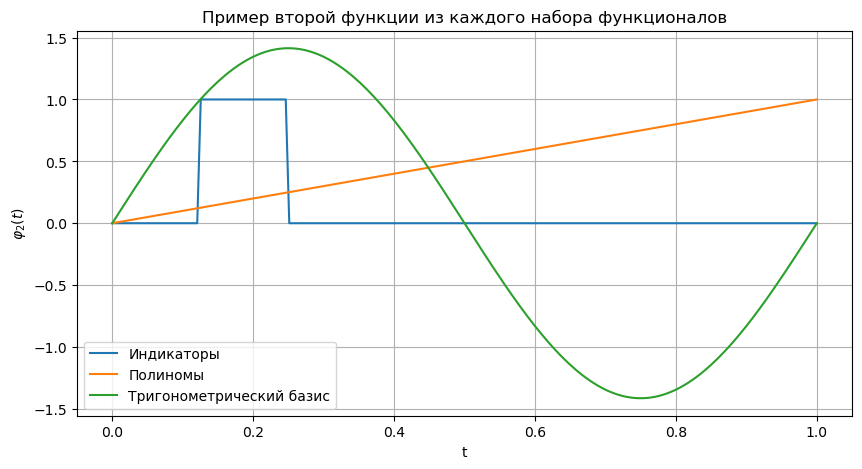

In [10]:
basis_builders = {
    "Индикаторы": make_indicator_basis,
    "Полиномы": make_polynomial_basis,
    "Тригонометрический базис": make_trigonometric_basis,
}

m_demo = 8

plt.figure(figsize=(10, 5))

for name, builder in basis_builders.items():
    basis, labels = builder(t, m_demo)
    plt.plot(t, basis[1], label=name)

plt.xlabel("t")
plt.ylabel(r"$\varphi_2(t)$")
plt.title("Пример второй функции из каждого набора функционалов")
plt.legend()
plt.grid(True)
plt.show()

## 8. Проверка линейности функционалов

Интегральный функционал

$$
L_\varphi(x)=\int_0^1 x(t)\varphi(t)\,dt
$$

является линейным, поскольку

$$
L_\varphi(x_1+x_2)=L_\varphi(x_1)+L_\varphi(x_2),
$$

$$
L_\varphi(\alpha x_1)=\alpha L_\varphi(x_1).
$$

Проверим эти свойства численно для одной функции $\varphi(t)$.

In [11]:
def check_linearity(x1, x2, phi, t, alpha=2.5):
    """Численная проверка линейности функционала L_phi."""
    left_add = inner_product(x1 + x2, phi, t)
    right_add = inner_product(x1, phi, t) + inner_product(x2, phi, t)

    left_hom = inner_product(alpha * x1, phi, t)
    right_hom = alpha * inner_product(x1, phi, t)

    return {
        "additivity_left": left_add,
        "additivity_right": right_add,
        "additivity_abs_error": abs(left_add - right_add),
        "homogeneity_left": left_hom,
        "homogeneity_right": right_hom,
        "homogeneity_abs_error": abs(left_hom - right_hom),
    }


basis_trig_demo, _ = make_trigonometric_basis(t, m=5)
phi = basis_trig_demo[1]

linearity_result = check_linearity(
    x1=X_func[0],
    x2=X_func[1],
    phi=phi,
    t=t,
    alpha=2.5,
)

pd.DataFrame([linearity_result])

/var/folders/qq/yzyzzd593z575k6v21b7crw40000gp/T/ipykernel_36350/24726087.py:3: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(f * g, t)


,additivity_left,additivity_right,additivity_abs_error,homogeneity_left,homogeneity_right,homogeneity_abs_error
0,-0.353366,-0.353366,0.0,0.548616,0.548616,0.0


## 9. Проверка ортонормированности тригонометрического базиса

Для ортонормированной системы должно выполняться

$$
\langle \varphi_k,\varphi_l\rangle = \delta_{kl}.
$$

То есть матрица Грама должна быть близка к единичной матрице.

/var/folders/qq/yzyzzd593z575k6v21b7crw40000gp/T/ipykernel_36350/24726087.py:3: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(f * g, t)


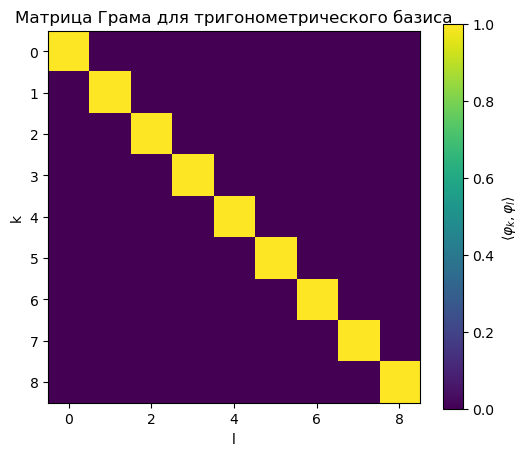

Максимальное отклонение от единичной матрицы: 0.000000


In [12]:
m_gram = 9

trig_basis, trig_labels = make_trigonometric_basis(t, m_gram)
G_trig = gram_matrix(trig_basis, t)

plt.figure(figsize=(6, 5))
plt.imshow(G_trig)
plt.colorbar(label=r"$\langle \varphi_k, \varphi_l \rangle$")
plt.title("Матрица Грама для тригонометрического базиса")
plt.xlabel("l")
plt.ylabel("k")
plt.show()

gram_error = np.max(np.abs(G_trig - np.eye(m_gram)))
print(f"Максимальное отклонение от единичной матрицы: {gram_error:.6f}")

## 10. Построение матрицы признаков $Z$

Для каждого набора функционалов строится своя матрица признаков

$$
Z = (z_{ik}), \qquad z_{ik}=\langle x_i,\varphi_k\rangle.
$$

Ниже показан пример построения $Z$ для тригонометрического базиса.

In [13]:
m_features = 8

basis_example, labels_example = make_trigonometric_basis(t, m_features)
Z_example = compute_feature_matrix(X_func, basis_example, t)

print("Размер матрицы признаков Z:", Z_example.shape)

pd.DataFrame(Z_example[:5], columns=labels_example)

Размер матрицы признаков Z: (500, 8)


/var/folders/qq/yzyzzd593z575k6v21b7crw40000gp/T/ipykernel_36350/24726087.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Z[:, k] = np.trapz(X_func * phi[None, :], t, axis=1)


,1,sqrt(2) sin(1·2πt),sqrt(2) cos(1·2πt),sqrt(2) sin(2·2πt),sqrt(2) cos(2·2πt),sqrt(2) sin(3·2πt),sqrt(2) cos(3·2πt),sqrt(2) sin(4·2πt)
0,-0.044362,0.219446,0.961057,0.016483,0.001602,-0.001977,-0.007545,0.008195
1,-0.377901,-0.572813,0.627756,0.081685,-0.008615,0.053497,-0.000068,0.046180
2,-0.220332,0.612075,-0.518223,0.043023,0.009133,0.035278,0.006598,0.023798
3,0.319659,0.531530,-1.052417,-0.064872,0.006605,-0.055119,-0.000959,-0.038918
4,-0.000096,-1.369849,-2.083726,0.006893,-0.007560,-0.001774,0.014915,-0.004335


## 11. МНК: ручная реализация и реализация через sklearn

Линейная модель имеет вид

$$
\widehat y = X\beta.
$$

Если добавить столбец единиц для свободного коэффициента, то решение МНК записывается как

$$
\widehat{\beta}=(X^TX)^{-1}X^Ty.
$$


In [14]:
def add_intercept(Z):
    """Добавляет столбец единиц к матрице признаков."""
    return np.column_stack([np.ones(Z.shape[0]), Z])


def fit_ols_manual(Z_train, y_train):
    """Оценка коэффициентов МНК через псевдообратную матрицу."""
    X_design = add_intercept(Z_train)
    beta = np.linalg.pinv(X_design) @ y_train
    return beta


def predict_ols_manual(Z, beta):
    """Прогноз ручной МНК-модели."""
    X_design = add_intercept(Z)
    return X_design @ beta


def fit_sklearn_linear(Z_train, y_train):
    """Линейная регрессия sklearn."""
    model = LinearRegression()
    model.fit(Z_train, y_train)
    return model


def sklearn_beta(model):
    """Возвращает коэффициенты sklearn-модели в формате [intercept, beta_1, ..., beta_m]."""
    return np.concatenate([[model.intercept_], model.coef_])

In [15]:
indices = np.arange(n_samples)

train_idx, test_idx = train_test_split(
    indices,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

Z_train = Z_example[train_idx]
Z_test = Z_example[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

beta_manual = fit_ols_manual(Z_train, y_train)
pred_manual = predict_ols_manual(Z_test, beta_manual)

model_sklearn = fit_sklearn_linear(Z_train, y_train)
pred_sklearn = model_sklearn.predict(Z_test)

comparison = pd.DataFrame({
    "manual_beta": beta_manual,
    "sklearn_beta": sklearn_beta(model_sklearn),
})

comparison

,manual_beta,sklearn_beta
0,-0.010912,-0.010912
1,-0.452373,-0.452373
2,1.644672,1.644672
3,-0.004632,-0.004632
4,0.398470,0.398470
5,0.133227,0.133227
6,-0.288995,-0.288995
7,-0.108328,-0.108328
8,0.589381,0.589381


## 12. Метрики качества

Для оценки качества используются:

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i-\widehat y_i)^2,
$$

$$
RMSE = \sqrt{MSE},
$$

$$
R^2 = 1-\frac{\sum_i (y_i-\widehat y_i)^2}{\sum_i (y_i-\bar y)^2}.
$$


In [16]:
def regression_metrics(y_true, y_pred):
    """Возвращает основные метрики регрессии."""
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return {
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
    }


manual_metrics = regression_metrics(y_test, pred_manual)
sklearn_metrics = regression_metrics(y_test, pred_sklearn)

pd.DataFrame([manual_metrics, sklearn_metrics], index=["Manual OLS", "Sklearn OLS"])

,MSE,RMSE,R2
Manual OLS,0.010344,0.101706,0.993591
Sklearn OLS,0.010344,0.101706,0.993591


## 13. Эксперимент 1: сравнение разных систем функционалов

Сравним три системы функционалов при одинаковом числе признаков $m$:

1. индикаторы подотрезков;
2. полиномиальные функционалы;
3. тригонометрический базис.

Для каждой системы обучается линейная модель и считаются метрики на обучающей и тестовой выборках.

In [17]:
def evaluate_basis_ols(name, basis, X_func, y, t, train_idx, test_idx):
    """Обучает МНК-модель для заданного базиса и возвращает метрики."""
    Z = compute_feature_matrix(X_func, basis, t)

    Z_train, Z_test = Z[train_idx], Z[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = LinearRegression()
    model.fit(Z_train, y_train)

    pred_train = model.predict(Z_train)
    pred_test = model.predict(Z_test)

    beta = sklearn_beta(model)

    train_metrics = regression_metrics(y_train, pred_train)
    test_metrics = regression_metrics(y_test, pred_test)

    X_design_train = add_intercept(Z_train)
    condition_number = np.linalg.cond(X_design_train)

    result = {
        "basis": name,
        "m": basis.shape[0],
        "MSE_train": train_metrics["MSE"],
        "RMSE_train": train_metrics["RMSE"],
        "R2_train": train_metrics["R2"],
        "MSE_test": test_metrics["MSE"],
        "RMSE_test": test_metrics["RMSE"],
        "R2_test": test_metrics["R2"],
        "coef_norm": np.linalg.norm(beta[1:]),
        "condition_number": condition_number,
    }

    return result, model, Z


m_compare = 8
comparison_results = []
fitted_models = {}
feature_matrices = {}

for name, builder in basis_builders.items():
    basis, labels = builder(t, m_compare)
    result, model, Z = evaluate_basis_ols(
        name=name,
        basis=basis,
        X_func=X_func,
        y=y,
        t=t,
        train_idx=train_idx,
        test_idx=test_idx,
    )

    comparison_results.append(result)
    fitted_models[name] = {
        "model": model,
        "basis": basis,
        "labels": labels,
    }
    feature_matrices[name] = Z

comparison_df = pd.DataFrame(comparison_results)
comparison_df.sort_values("MSE_test")

/var/folders/qq/yzyzzd593z575k6v21b7crw40000gp/T/ipykernel_36350/24726087.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Z[:, k] = np.trapz(X_func * phi[None, :], t, axis=1)
/var/folders/qq/yzyzzd593z575k6v21b7crw40000gp/T/ipykernel_36350/24726087.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Z[:, k] = np.trapz(X_func * phi[None, :], t, axis=1)
/var/folders/qq/yzyzzd593z575k6v21b7crw40000gp/T/ipykernel_36350/24726087.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Z[:, k] = np.trapz(X_func * phi[None, :], t, axis=1)


,basis,m,MSE_train,RMSE_train,R2_train,MSE_test,RMSE_test,R2_test,coef_norm,condition_number
2,Тригонометрический базис,8,0.009378,0.096838,0.994218,0.010344,0.101706,0.993591,1.878499,1.533548e+02
0,Индикаторы,8,0.009382,0.096862,0.994215,0.010437,0.102162,0.993533,5.418945,4.351388e+02
1,Полиномы,8,0.009339,0.096638,0.994242,0.010540,0.102667,0.993469,48360.978220,1.389650e+07


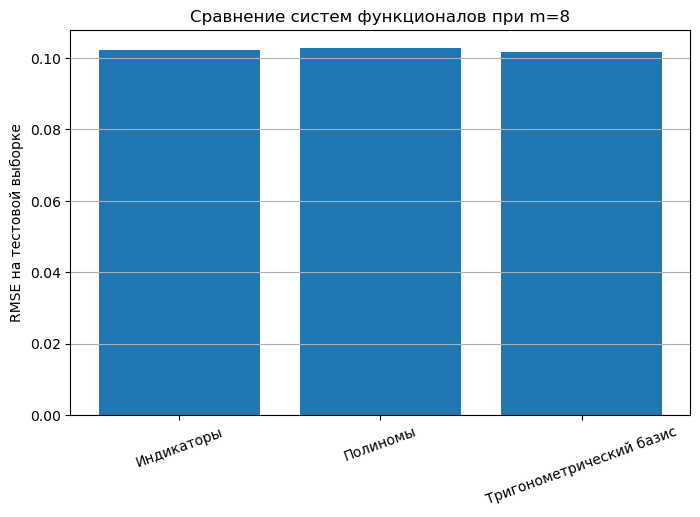

In [18]:
plt.figure(figsize=(8, 5))

plt.bar(comparison_df["basis"], comparison_df["RMSE_test"])
plt.ylabel("RMSE на тестовой выборке")
plt.title(f"Сравнение систем функционалов при m={m_compare}")
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.show()

## 14. Эксперимент 2: влияние числа функционалов $m$

Теперь изменим число функционалов $m$ и посмотрим, как меняется качество модели.  
Ожидаемая картина: при увеличении $m$ ошибка на обучении обычно уменьшается, а ошибка на тестовой выборке может сначала уменьшаться, затем стабилизироваться или расти.

In [19]:
def run_m_experiment(
    X_func,
    y,
    t,
    train_idx,
    test_idx,
    m_values,
    basis_builders,
):
    """Сравнение качества моделей при разном числе функционалов m."""
    rows = []

    for basis_name, builder in basis_builders.items():
        for m in m_values:
            basis, labels = builder(t, m)
            Z = compute_feature_matrix(X_func, basis, t)

            Z_train, Z_test = Z[train_idx], Z[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            model = LinearRegression()
            model.fit(Z_train, y_train)

            pred_train = model.predict(Z_train)
            pred_test = model.predict(Z_test)

            train_metrics = regression_metrics(y_train, pred_train)
            test_metrics = regression_metrics(y_test, pred_test)

            rows.append({
                "basis": basis_name,
                "m": m,
                "MSE_train": train_metrics["MSE"],
                "RMSE_train": train_metrics["RMSE"],
                "R2_train": train_metrics["R2"],
                "MSE_test": test_metrics["MSE"],
                "RMSE_test": test_metrics["RMSE"],
                "R2_test": test_metrics["R2"],
            })

    return pd.DataFrame(rows)


m_values = [2, 3, 4, 5, 8, 12, 16, 20, 30]

m_results = run_m_experiment(
    X_func=X_func,
    y=y,
    t=t,
    train_idx=train_idx,
    test_idx=test_idx,
    m_values=m_values,
    basis_builders=basis_builders,
)

m_results.head()

/var/folders/qq/yzyzzd593z575k6v21b7crw40000gp/T/ipykernel_36350/24726087.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Z[:, k] = np.trapz(X_func * phi[None, :], t, axis=1)
/var/folders/qq/yzyzzd593z575k6v21b7crw40000gp/T/ipykernel_36350/24726087.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Z[:, k] = np.trapz(X_func * phi[None, :], t, axis=1)
/var/folders/qq/yzyzzd593z575k6v21b7crw40000gp/T/ipykernel_36350/24726087.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Z[:, k] = np.trapz(X_func * phi[None, :], t, axis=1)
/var/folders/qq/yzyzzd593z575k6v21b7crw40000gp/T/ipykernel_36350/24726087.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration

,basis,m,MSE_train,RMSE_train,R2_train,MSE_test,RMSE_test,R2_test
0,Индикаторы,2,0.009453,0.097228,0.994172,0.010363,0.101800,0.993579
1,Индикаторы,3,0.009383,0.096865,0.994215,0.010576,0.102841,0.993447
2,Индикаторы,4,0.009406,0.096984,0.994201,0.010482,0.102382,0.993505
3,Индикаторы,5,0.009330,0.096589,0.994248,0.010271,0.101345,0.993636
4,Индикаторы,8,0.009382,0.096862,0.994215,0.010437,0.102162,0.993533


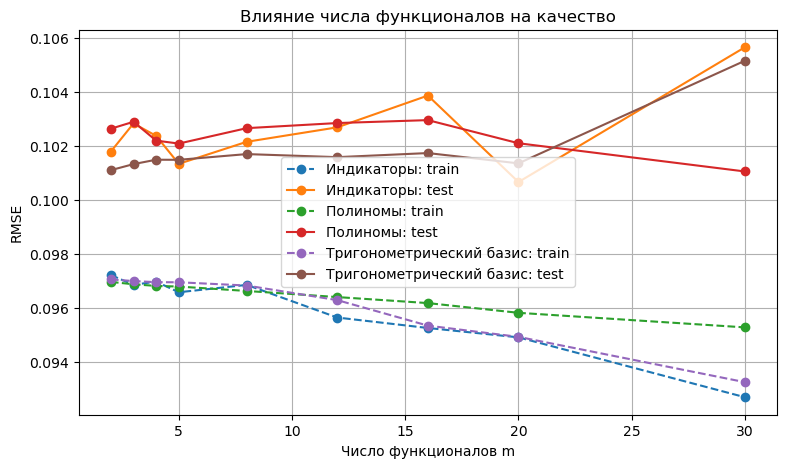

In [20]:
plt.figure(figsize=(9, 5))

for basis_name in m_results["basis"].unique():
    subset = m_results[m_results["basis"] == basis_name]
    plt.plot(subset["m"], subset["RMSE_train"], marker="o", linestyle="--", label=f"{basis_name}: train")
    plt.plot(subset["m"], subset["RMSE_test"], marker="o", label=f"{basis_name}: test")

plt.xlabel("Число функционалов m")
plt.ylabel("RMSE")
plt.title("Влияние числа функционалов на качество")
plt.legend()
plt.grid(True)
plt.show()

In [42]:
best_by_m = (
    m_results.sort_values("RMSE_test")
    .groupby("basis", as_index=False)
    .head(20)
)

best_by_m

,basis,m,MSE_train,RMSE_train,R2_train,MSE_test,RMSE_test,R2_test
7,Индикаторы,20,0.009010,0.094920,0.994445,0.010135,0.100671,0.993720
17,Полиномы,30,0.009080,0.095289,0.994402,0.010214,0.101063,0.993671
18,Тригонометрический базис,2,0.009422,0.097065,0.994191,0.010224,0.101111,0.993665
19,Тригонометрический базис,3,0.009410,0.097005,0.994198,0.010269,0.101335,0.993637
3,Индикаторы,5,0.009330,0.096589,0.994248,0.010271,0.101345,0.993636
25,Тригонометрический базис,20,0.009013,0.094938,0.994443,0.010274,0.101363,0.993634
21,Тригонометрический базис,5,0.009401,0.096959,0.994204,0.010301,0.101494,0.993617
20,Тригонометрический базис,4,0.009402,0.096963,0.994203,0.010302,0.101498,0.993617
23,Тригонометрический базис,12,0.009273,0.096297,0.994283,0.010321,0.101593,0.993605
22,Тригонометрический базис,8,0.009378,0.096838,0.994218,0.010344,0.101706,0.993591


## 15. Эксперимент 3: восстановление весовой функции $w(t)$

После обучения линейной модели можно восстановить весовую функцию

$$
\widehat w(t)=\sum_{k=1}^{m}\widehat\beta_k\varphi_k(t).
$$

Если модель хорошо восстановила структуру зависимости, то $\widehat w(t)$ должна быть близка к $w_{\text{true}}(t)$.

/var/folders/qq/yzyzzd593z575k6v21b7crw40000gp/T/ipykernel_36350/24726087.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Z[:, k] = np.trapz(X_func * phi[None, :], t, axis=1)
/var/folders/qq/yzyzzd593z575k6v21b7crw40000gp/T/ipykernel_36350/24726087.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Z[:, k] = np.trapz(X_func * phi[None, :], t, axis=1)
/var/folders/qq/yzyzzd593z575k6v21b7crw40000gp/T/ipykernel_36350/24726087.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Z[:, k] = np.trapz(X_func * phi[None, :], t, axis=1)


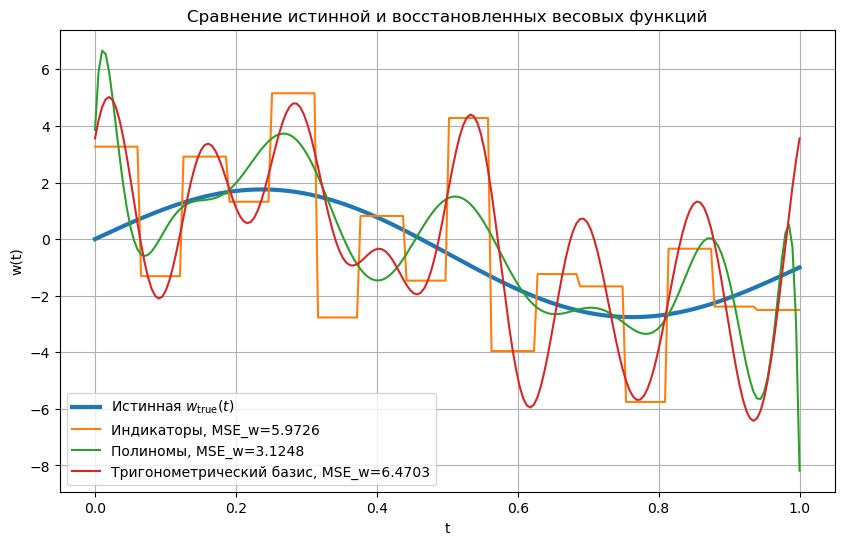

,basis,m,MSE_w,coef_norm
1,Полиномы,16,3.124801,4.789373e+09
0,Индикаторы,16,5.972623,1.196551e+01
2,Тригонометрический базис,16,6.470258,3.066461e+00


In [22]:
def reconstruct_weight_function(model, basis):
    """Восстанавливает w_hat(t) = sum beta_k * phi_k(t)."""
    return model.coef_ @ basis


m_weight = 16

plt.figure(figsize=(10, 6))
plt.plot(t, w_true, linewidth=3, label=r"Истинная $w_{\mathrm{true}}(t)$")

weight_rows = []

for name, builder in basis_builders.items():
    basis, labels = builder(t, m_weight)
    Z = compute_feature_matrix(X_func, basis, t)

    Z_train, Z_test = Z[train_idx], Z[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = LinearRegression()
    model.fit(Z_train, y_train)

    w_hat = reconstruct_weight_function(model, basis)
    w_mse = mean_squared_error(w_true, w_hat)

    weight_rows.append({
        "basis": name,
        "m": m_weight,
        "MSE_w": w_mse,
        "coef_norm": np.linalg.norm(model.coef_),
    })

    plt.plot(t, w_hat, label=f"{name}, MSE_w={w_mse:.4f}")

plt.xlabel("t")
plt.ylabel("w(t)")
plt.title("Сравнение истинной и восстановленных весовых функций")
plt.legend()
plt.grid(True)
plt.show()

weight_df = pd.DataFrame(weight_rows).sort_values("MSE_w")
weight_df

## 16. Эксперимент 4: ridge-регрессия

Обычный МНК может быть неустойчивым, если признаки коррелируют или число функционалов достаточно велико.  
Для повышения устойчивости используется ridge-регрессия:

$$
Q_\lambda(\beta)=
(y-X\beta)^T(y-X\beta)+\lambda\|\beta\|_2^2.
$$

Параметр $\lambda$ ограничивает рост коэффициентов. При $\lambda=0$ модель близка к обычному МНК, а при слишком большом $\lambda$ коэффициенты чрезмерно сжимаются к нулю.

In [23]:
def evaluate_ridge_for_basis(
    name,
    basis,
    X_func,
    y,
    t,
    train_idx,
    test_idx,
    alpha=1.0,
):
    """Обучает ridge-регрессию для заданного базиса и возвращает метрики."""
    Z = compute_feature_matrix(X_func, basis, t)

    Z_train, Z_test = Z[train_idx], Z[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = Ridge(alpha=alpha)
    model.fit(Z_train, y_train)

    pred_train = model.predict(Z_train)
    pred_test = model.predict(Z_test)

    train_metrics = regression_metrics(y_train, pred_train)
    test_metrics = regression_metrics(y_test, pred_test)

    return {
        "basis": name,
        "m": basis.shape[0],
        "alpha": alpha,
        "MSE_train": train_metrics["MSE"],
        "RMSE_train": train_metrics["RMSE"],
        "R2_train": train_metrics["R2"],
        "MSE_test": test_metrics["MSE"],
        "RMSE_test": test_metrics["RMSE"],
        "R2_test": test_metrics["R2"],
        "coef_norm": np.linalg.norm(model.coef_),
    }, model


m_ridge = 20
alpha_ridge = 1.0

ridge_rows = []

for name, builder in basis_builders.items():
    basis, labels = builder(t, m_ridge)
    row, model = evaluate_ridge_for_basis(
        name=name,
        basis=basis,
        X_func=X_func,
        y=y,
        t=t,
        train_idx=train_idx,
        test_idx=test_idx,
        alpha=alpha_ridge,
    )
    ridge_rows.append(row)

ridge_df = pd.DataFrame(ridge_rows).sort_values("RMSE_test")
ridge_df

/var/folders/qq/yzyzzd593z575k6v21b7crw40000gp/T/ipykernel_36350/24726087.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Z[:, k] = np.trapz(X_func * phi[None, :], t, axis=1)
/var/folders/qq/yzyzzd593z575k6v21b7crw40000gp/T/ipykernel_36350/24726087.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Z[:, k] = np.trapz(X_func * phi[None, :], t, axis=1)
/var/folders/qq/yzyzzd593z575k6v21b7crw40000gp/T/ipykernel_36350/24726087.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Z[:, k] = np.trapz(X_func * phi[None, :], t, axis=1)


,basis,m,alpha,MSE_train,RMSE_train,R2_train,MSE_test,RMSE_test,R2_test,coef_norm
2,Тригонометрический базис,20,1.0,0.009426,0.097089,0.994188,0.010358,0.101775,0.993582,1.722180
1,Полиномы,20,1.0,0.016844,0.129785,0.989615,0.019046,0.138008,0.988199,5.111943
0,Индикаторы,20,1.0,0.022504,0.150014,0.986125,0.024035,0.155031,0.985108,7.038170


In [24]:
ols_rows_for_compare = []

for name, builder in basis_builders.items():
    basis, labels = builder(t, m_ridge)
    row, model, Z = evaluate_basis_ols(
        name=name,
        basis=basis,
        X_func=X_func,
        y=y,
        t=t,
        train_idx=train_idx,
        test_idx=test_idx,
    )
    row["model"] = "OLS"
    ols_rows_for_compare.append(row)

ridge_for_compare = ridge_df.copy()
ridge_for_compare["model"] = "Ridge"

ols_for_compare = pd.DataFrame(ols_rows_for_compare)
ols_for_compare["alpha"] = 0.0

ols_ridge_compare = pd.concat([
    ols_for_compare[["basis", "model", "m", "alpha", "RMSE_test", "R2_test", "coef_norm"]],
    ridge_for_compare[["basis", "model", "m", "alpha", "RMSE_test", "R2_test", "coef_norm"]],
])

ols_ridge_compare.sort_values(["basis", "model"])

/var/folders/qq/yzyzzd593z575k6v21b7crw40000gp/T/ipykernel_36350/24726087.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Z[:, k] = np.trapz(X_func * phi[None, :], t, axis=1)
/var/folders/qq/yzyzzd593z575k6v21b7crw40000gp/T/ipykernel_36350/24726087.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Z[:, k] = np.trapz(X_func * phi[None, :], t, axis=1)
/var/folders/qq/yzyzzd593z575k6v21b7crw40000gp/T/ipykernel_36350/24726087.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Z[:, k] = np.trapz(X_func * phi[None, :], t, axis=1)


,basis,model,m,alpha,RMSE_test,R2_test,coef_norm
0,Индикаторы,OLS,20,0.0,0.100671,0.993720,1.490231e+01
0,Индикаторы,Ridge,20,1.0,0.155031,0.985108,7.038170e+00
1,Полиномы,OLS,20,0.0,0.102108,0.993540,3.039836e+10
1,Полиномы,Ridge,20,1.0,0.138008,0.988199,5.111943e+00
2,Тригонометрический базис,OLS,20,0.0,0.101363,0.993634,3.312277e+00
2,Тригонометрический базис,Ridge,20,1.0,0.101775,0.993582,1.722180e+00


## 17. Эксперимент 5: зависимость качества от параметра $\lambda$

Теперь исследуем, как значение параметра регуляризации влияет на качество модели.

In [25]:
def run_lambda_experiment(
    X_func,
    y,
    t,
    train_idx,
    test_idx,
    basis_builders,
    m=20,
    lambdas=None,
):
    """Оценка ridge-регрессии при разных lambda."""
    if lambdas is None:
        lambdas = np.logspace(-4, 3, 25)

    rows = []

    for basis_name, builder in basis_builders.items():
        basis, labels = builder(t, m)
        Z = compute_feature_matrix(X_func, basis, t)

        Z_train, Z_test = Z[train_idx], Z[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        for alpha in lambdas:
            model = Ridge(alpha=alpha)
            model.fit(Z_train, y_train)

            pred_test = model.predict(Z_test)
            test_metrics = regression_metrics(y_test, pred_test)

            rows.append({
                "basis": basis_name,
                "m": m,
                "lambda": alpha,
                "MSE_test": test_metrics["MSE"],
                "RMSE_test": test_metrics["RMSE"],
                "R2_test": test_metrics["R2"],
                "coef_norm": np.linalg.norm(model.coef_),
            })

    return pd.DataFrame(rows)


lambdas = np.logspace(-4, 3, 25)

lambda_results = run_lambda_experiment(
    X_func=X_func,
    y=y,
    t=t,
    train_idx=train_idx,
    test_idx=test_idx,
    basis_builders=basis_builders,
    m=20,
    lambdas=lambdas,
)

lambda_results.head()

/var/folders/qq/yzyzzd593z575k6v21b7crw40000gp/T/ipykernel_36350/24726087.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Z[:, k] = np.trapz(X_func * phi[None, :], t, axis=1)
/var/folders/qq/yzyzzd593z575k6v21b7crw40000gp/T/ipykernel_36350/24726087.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Z[:, k] = np.trapz(X_func * phi[None, :], t, axis=1)
/var/folders/qq/yzyzzd593z575k6v21b7crw40000gp/T/ipykernel_36350/24726087.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Z[:, k] = np.trapz(X_func * phi[None, :], t, axis=1)


,basis,m,lambda,MSE_test,RMSE_test,R2_test,coef_norm
0,Индикаторы,20,0.000100,0.010108,0.100539,0.993737,13.757893
1,Индикаторы,20,0.000196,0.010095,0.100474,0.993745,12.906454
2,Индикаторы,20,0.000383,0.010087,0.100436,0.993750,11.693440
3,Индикаторы,20,0.000750,0.010098,0.100488,0.993743,10.289045
4,Индикаторы,20,0.001468,0.010133,0.100661,0.993722,9.059771


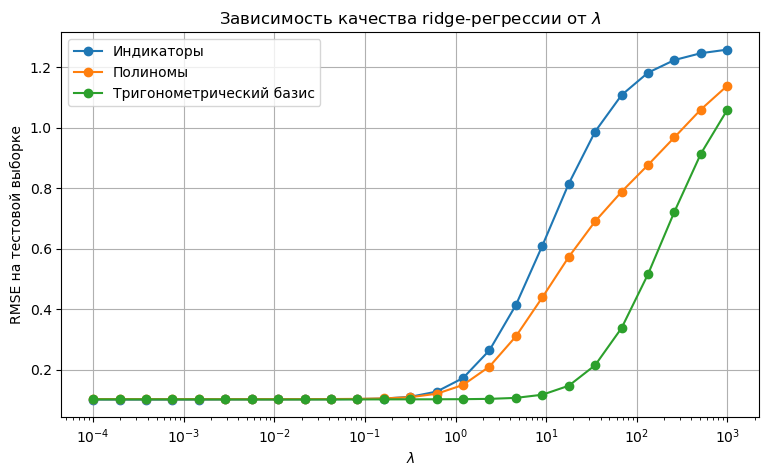

,basis,m,lambda,MSE_test,RMSE_test,R2_test,coef_norm
0,Индикаторы,20,0.000383,0.010087,0.100436,0.993750,11.693440
1,Полиномы,20,0.002873,0.010396,0.101960,0.993559,5.663443
2,Тригонометрический базис,20,0.021544,0.010172,0.100856,0.993697,2.158656


In [26]:
plt.figure(figsize=(9, 5))

for basis_name in lambda_results["basis"].unique():
    subset = lambda_results[lambda_results["basis"] == basis_name]
    plt.plot(subset["lambda"], subset["RMSE_test"], marker="o", label=basis_name)

plt.xscale("log")
plt.xlabel(r"$\lambda$")
plt.ylabel("RMSE на тестовой выборке")
plt.title(r"Зависимость качества ridge-регрессии от $\lambda$")
plt.legend()
plt.grid(True)
plt.show()

best_lambda = (
    lambda_results.sort_values("RMSE_test")
    .groupby("basis", as_index=False)
    .first()
)

best_lambda

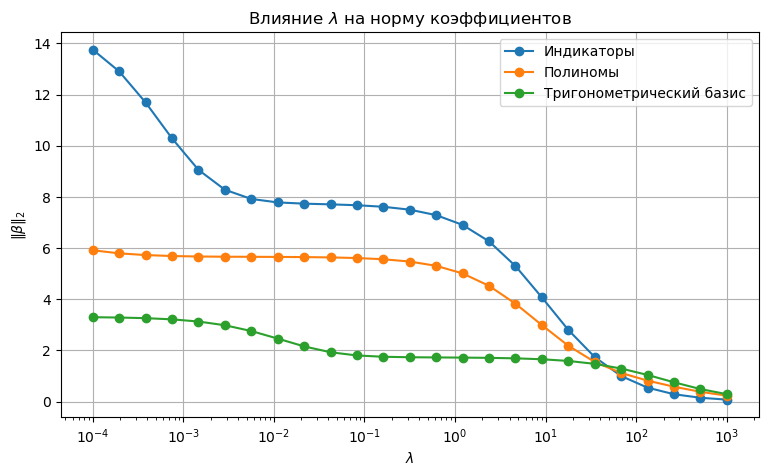

In [27]:
plt.figure(figsize=(9, 5))

for basis_name in lambda_results["basis"].unique():
    subset = lambda_results[lambda_results["basis"] == basis_name]
    plt.plot(subset["lambda"], subset["coef_norm"], marker="o", label=basis_name)

plt.xscale("log")
plt.xlabel(r"$\lambda$")
plt.ylabel(r"$\|\beta\|_2$")
plt.title(r"Влияние $\lambda$ на норму коэффициентов")
plt.legend()
plt.grid(True)
plt.show()

## 18. Эксперимент 6: устойчивость к шуму

Проверим, как качество модели меняется при увеличении шума в функциональных наблюдениях.  
Для простоты сравним обычный МНК и ridge-регрессию на тригонометрическом базисе.

In [28]:
def evaluate_single_model(Z_train, Z_test, y_train, y_test, model):
    """Обучает модель и возвращает метрики на тестовой выборке."""
    model.fit(Z_train, y_train)
    pred_test = model.predict(Z_test)
    metrics = regression_metrics(y_test, pred_test)
    return metrics, np.linalg.norm(model.coef_)


def run_noise_experiment(
    sigma_x_values,
    n_repeats=5,
    n_samples=500,
    n_grid=200,
    m=16,
    sigma_y=0.10,
    ridge_alpha=1.0,
):
    """Исследует устойчивость OLS и Ridge к шуму в функциях."""
    rows = []

    for sigma_x in sigma_x_values:
        for repeat in range(n_repeats):
            seed = RANDOM_STATE + 100 * repeat

            t_noise, X_noise, y_noise, _, _, _ = generate_smooth_functional_data(
                n_samples=n_samples,
                n_grid=n_grid,
                sigma_x=sigma_x,
                sigma_y=sigma_y,
                random_state=seed,
            )

            idx = np.arange(n_samples)
            train_idx_noise, test_idx_noise = train_test_split(
                idx,
                test_size=TEST_SIZE,
                random_state=seed,
            )

            basis, labels = make_trigonometric_basis(t_noise, m)
            Z = compute_feature_matrix(X_noise, basis, t_noise)

            Z_train, Z_test = Z[train_idx_noise], Z[test_idx_noise]
            y_train, y_test = y_noise[train_idx_noise], y_noise[test_idx_noise]

            for model_name, model in [
                ("OLS", LinearRegression()),
                ("Ridge", Ridge(alpha=ridge_alpha)),
            ]:
                metrics, coef_norm = evaluate_single_model(
                    Z_train,
                    Z_test,
                    y_train,
                    y_test,
                    model,
                )

                rows.append({
                    "sigma_x": sigma_x,
                    "repeat": repeat,
                    "model": model_name,
                    "RMSE_test": metrics["RMSE"],
                    "R2_test": metrics["R2"],
                    "coef_norm": coef_norm,
                })

    return pd.DataFrame(rows)


sigma_x_values = [0.00, 0.05, 0.10, 0.20, 0.40]

noise_results_raw = run_noise_experiment(
    sigma_x_values=sigma_x_values,
    n_repeats=5,
    n_samples=500,
    n_grid=200,
    m=16,
    sigma_y=0.10,
    ridge_alpha=1.0,
)

noise_results = (
    noise_results_raw
    .groupby(["sigma_x", "model"], as_index=False)
    .agg(
        RMSE_test_mean=("RMSE_test", "mean"),
        RMSE_test_std=("RMSE_test", "std"),
        R2_test_mean=("R2_test", "mean"),
        coef_norm_mean=("coef_norm", "mean"),
    )
)

noise_results

/var/folders/qq/yzyzzd593z575k6v21b7crw40000gp/T/ipykernel_36350/1137088402.py:36: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  y_clean = np.trapz(X_func * w_true[None, :], t, axis=1)
/var/folders/qq/yzyzzd593z575k6v21b7crw40000gp/T/ipykernel_36350/24726087.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Z[:, k] = np.trapz(X_func * phi[None, :], t, axis=1)
/var/folders/qq/yzyzzd593z575k6v21b7crw40000gp/T/ipykernel_36350/1137088402.py:36: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  y_clean = np.trapz(X_func * w_true[None, :], t, axis=1)
/var/folders/qq/yzyzzd593z575k6v21b7crw40000gp/T/ipykernel_36350/24726087.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical i

,sigma_x,model,RMSE_test_mean,RMSE_test_std,R2_test_mean,coef_norm_mean
0,0.00,OLS,0.102212,0.004743,0.994212,1.725148
1,0.00,Ridge,0.102647,0.005506,0.994152,1.717156
2,0.05,OLS,0.103510,0.003675,0.994081,5.303272
3,0.05,Ridge,0.102627,0.005488,0.994154,1.717310
4,0.10,OLS,0.103487,0.003669,0.994084,3.049953
5,0.10,Ridge,0.102605,0.005453,0.994156,1.717761
6,0.20,OLS,0.103442,0.003658,0.994089,2.138427
7,0.20,Ridge,0.102564,0.005339,0.994163,1.719327
8,0.40,OLS,0.103359,0.003635,0.994102,1.837850
9,0.40,Ridge,0.102527,0.005026,0.994176,1.723025


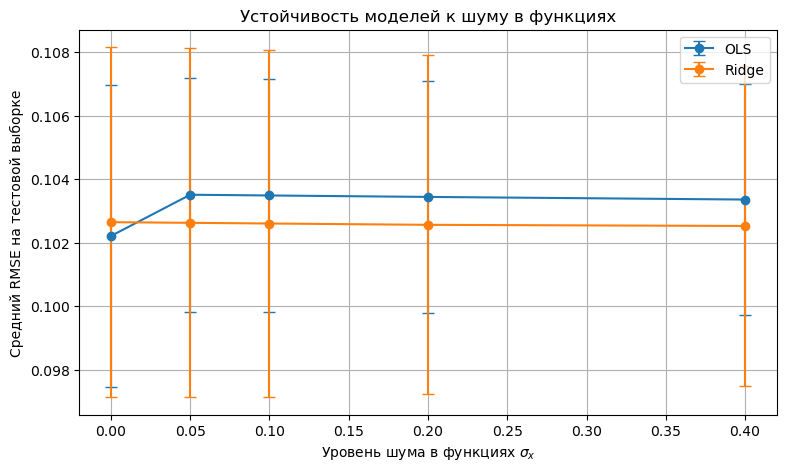

In [29]:
plt.figure(figsize=(9, 5))

for model_name in noise_results["model"].unique():
    subset = noise_results[noise_results["model"] == model_name]
    plt.errorbar(
        subset["sigma_x"],
        subset["RMSE_test_mean"],
        yerr=subset["RMSE_test_std"],
        marker="o",
        capsize=4,
        label=model_name,
    )

plt.xlabel(r"Уровень шума в функциях $\sigma_x$")
plt.ylabel("Средний RMSE на тестовой выборке")
plt.title("Устойчивость моделей к шуму в функциях")
plt.legend()
plt.grid(True)
plt.show()

## 19. Эксперимент 7: устойчивость к изменению сетки

Теперь проверим, насколько качество зависит от числа точек сетки.  
Если сетка слишком грубая, численное интегрирование становится менее точным. При достаточно плотной сетке качество должно стабилизироваться.

In [30]:
def run_grid_experiment(
    grid_values,
    n_samples=500,
    sigma_x=0.10,
    sigma_y=0.10,
    m=16,
    ridge_alpha=1.0,
):
    """Исследует зависимость качества от числа точек сетки."""
    rows = []

    for grid_size in grid_values:
        t_grid, X_grid, y_grid, _, _, _ = generate_smooth_functional_data(
            n_samples=n_samples,
            n_grid=grid_size,
            sigma_x=sigma_x,
            sigma_y=sigma_y,
            random_state=RANDOM_STATE,
        )

        idx = np.arange(n_samples)
        train_idx_grid, test_idx_grid = train_test_split(
            idx,
            test_size=TEST_SIZE,
            random_state=RANDOM_STATE,
        )

        basis, labels = make_trigonometric_basis(t_grid, m)
        Z = compute_feature_matrix(X_grid, basis, t_grid)

        Z_train, Z_test = Z[train_idx_grid], Z[test_idx_grid]
        y_train, y_test = y_grid[train_idx_grid], y_grid[test_idx_grid]

        for model_name, model in [
            ("OLS", LinearRegression()),
            ("Ridge", Ridge(alpha=ridge_alpha)),
        ]:
            metrics, coef_norm = evaluate_single_model(
                Z_train,
                Z_test,
                y_train,
                y_test,
                model,
            )

            rows.append({
                "n_grid": grid_size,
                "model": model_name,
                "RMSE_test": metrics["RMSE"],
                "R2_test": metrics["R2"],
                "coef_norm": coef_norm,
            })

    return pd.DataFrame(rows)


grid_values = [25, 50, 100, 200, 500]

grid_results = run_grid_experiment(
    grid_values=grid_values,
    n_samples=500,
    sigma_x=0.10,
    sigma_y=0.10,
    m=16,
    ridge_alpha=1.0,
)

grid_results

/var/folders/qq/yzyzzd593z575k6v21b7crw40000gp/T/ipykernel_36350/1137088402.py:36: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  y_clean = np.trapz(X_func * w_true[None, :], t, axis=1)
/var/folders/qq/yzyzzd593z575k6v21b7crw40000gp/T/ipykernel_36350/24726087.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Z[:, k] = np.trapz(X_func * phi[None, :], t, axis=1)
/var/folders/qq/yzyzzd593z575k6v21b7crw40000gp/T/ipykernel_36350/1137088402.py:36: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  y_clean = np.trapz(X_func * w_true[None, :], t, axis=1)
/var/folders/qq/yzyzzd593z575k6v21b7crw40000gp/T/ipykernel_36350/24726087.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical i

,n_grid,model,RMSE_test,R2_test,coef_norm
0,25,OLS,0.108607,0.992819,2.282273
1,25,Ridge,0.106771,0.993060,1.730196
2,50,OLS,0.112329,0.991905,2.425864
3,50,Ridge,0.109484,0.992310,1.727743
4,100,OLS,0.108346,0.992667,3.050365
5,100,Ridge,0.103489,0.993309,1.718248
6,200,OLS,0.101744,0.993586,3.066461
7,200,Ridge,0.101777,0.993582,1.722336
8,500,OLS,0.097498,0.994053,6.193500
9,500,Ridge,0.090657,0.994858,1.719436


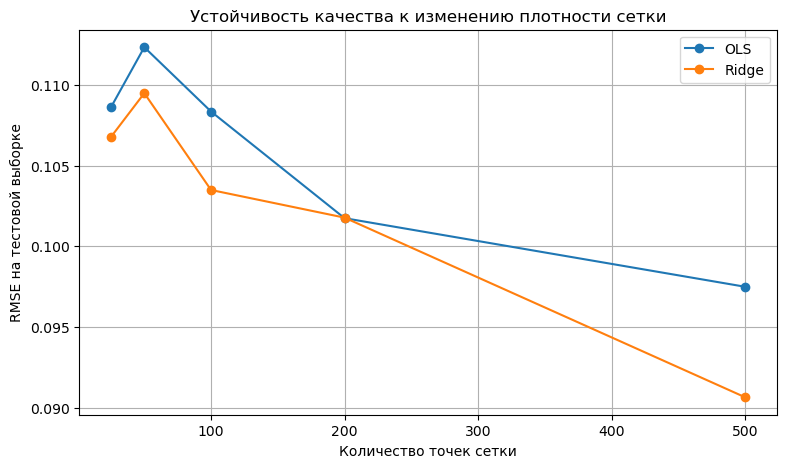

In [31]:
plt.figure(figsize=(9, 5))

for model_name in grid_results["model"].unique():
    subset = grid_results[grid_results["model"] == model_name]
    plt.plot(subset["n_grid"], subset["RMSE_test"], marker="o", label=model_name)

plt.xlabel("Количество точек сетки")
plt.ylabel("RMSE на тестовой выборке")
plt.title("Устойчивость качества к изменению плотности сетки")
plt.legend()
plt.grid(True)
plt.show()

## 20. Сводная таблица результатов

Соберём основные результаты экспериментов:

1. качество разных систем функционалов при фиксированном $m$;
2. лучшее качество при подборе числа функционалов;
3. лучшее качество ridge-регрессии при подборе $\lambda$;
4. качество при разных уровнях шума;
5. качество при разных размерах сетки.

In [32]:
print("Сравнение систем функционалов при фиксированном m:")
display(comparison_df.sort_values("RMSE_test"))

print("Лучшее m для каждой системы функционалов:")
display(best_by_m)

print("Лучшее lambda для каждой системы функционалов:")
display(best_lambda)

print("Устойчивость к шуму:")
display(noise_results)

print("Устойчивость к изменению сетки:")
display(grid_results)

Сравнение систем функционалов при фиксированном m:


,basis,m,MSE_train,RMSE_train,R2_train,MSE_test,RMSE_test,R2_test,coef_norm,condition_number
2,Тригонометрический базис,8,0.009378,0.096838,0.994218,0.010344,0.101706,0.993591,1.878499,1.533548e+02
0,Индикаторы,8,0.009382,0.096862,0.994215,0.010437,0.102162,0.993533,5.418945,4.351388e+02
1,Полиномы,8,0.009339,0.096638,0.994242,0.010540,0.102667,0.993469,48360.978220,1.389650e+07


Лучшее m для каждой системы функционалов:


,basis,m,MSE_train,RMSE_train,R2_train,MSE_test,RMSE_test,R2_test
0,Индикаторы,20,0.009010,0.094920,0.994445,0.010135,0.100671,0.993720
1,Полиномы,30,0.009080,0.095289,0.994402,0.010214,0.101063,0.993671
2,Тригонометрический базис,2,0.009422,0.097065,0.994191,0.010224,0.101111,0.993665


Лучшее lambda для каждой системы функционалов:


,basis,m,lambda,MSE_test,RMSE_test,R2_test,coef_norm
0,Индикаторы,20,0.000383,0.010087,0.100436,0.993750,11.693440
1,Полиномы,20,0.002873,0.010396,0.101960,0.993559,5.663443
2,Тригонометрический базис,20,0.021544,0.010172,0.100856,0.993697,2.158656


Устойчивость к шуму:


,sigma_x,model,RMSE_test_mean,RMSE_test_std,R2_test_mean,coef_norm_mean
0,0.00,OLS,0.102212,0.004743,0.994212,1.725148
1,0.00,Ridge,0.102647,0.005506,0.994152,1.717156
2,0.05,OLS,0.103510,0.003675,0.994081,5.303272
3,0.05,Ridge,0.102627,0.005488,0.994154,1.717310
4,0.10,OLS,0.103487,0.003669,0.994084,3.049953
5,0.10,Ridge,0.102605,0.005453,0.994156,1.717761
6,0.20,OLS,0.103442,0.003658,0.994089,2.138427
7,0.20,Ridge,0.102564,0.005339,0.994163,1.719327
8,0.40,OLS,0.103359,0.003635,0.994102,1.837850
9,0.40,Ridge,0.102527,0.005026,0.994176,1.723025


Устойчивость к изменению сетки:


,n_grid,model,RMSE_test,R2_test,coef_norm
0,25,OLS,0.108607,0.992819,2.282273
1,25,Ridge,0.106771,0.993060,1.730196
2,50,OLS,0.112329,0.991905,2.425864
3,50,Ridge,0.109484,0.992310,1.727743
4,100,OLS,0.108346,0.992667,3.050365
5,100,Ridge,0.103489,0.993309,1.718248
6,200,OLS,0.101744,0.993586,3.066461
7,200,Ridge,0.101777,0.993582,1.722336
8,500,OLS,0.097498,0.994053,6.193500
9,500,Ridge,0.090657,0.994858,1.719436


In [33]:
summary_rows = []

best_fixed = comparison_df.sort_values("RMSE_test").iloc[0]
summary_rows.append({
    "experiment": "Фиксированное m",
    "best_setting": f"{best_fixed['basis']}, m={int(best_fixed['m'])}",
    "RMSE_test": best_fixed["RMSE_test"],
    "R2_test": best_fixed["R2_test"],
})

best_m_row = m_results.sort_values("RMSE_test").iloc[0]
summary_rows.append({
    "experiment": "Подбор m",
    "best_setting": f"{best_m_row['basis']}, m={int(best_m_row['m'])}",
    "RMSE_test": best_m_row["RMSE_test"],
    "R2_test": best_m_row["R2_test"],
})

best_lambda_row = lambda_results.sort_values("RMSE_test").iloc[0]
summary_rows.append({
    "experiment": "Ridge: подбор lambda",
    "best_setting": f"{best_lambda_row['basis']}, m={int(best_lambda_row['m'])}, lambda={best_lambda_row['lambda']:.4g}",
    "RMSE_test": best_lambda_row["RMSE_test"],
    "R2_test": best_lambda_row["R2_test"],
})

summary_df = pd.DataFrame(summary_rows)
summary_df

,experiment,best_setting,RMSE_test,R2_test
0,Фиксированное m,"Тригонометрический базис, m=8",0.101706,0.993591
1,Подбор m,"Индикаторы, m=20",0.100671,0.993720
2,Ridge: подбор lambda,"Индикаторы, m=20, lambda=0.0003831",0.100436,0.993750


## 21. Итоговые выводы


1. Синтетические функциональные данные позволяют проверить модель в контролируемой постановке, потому что истинная весовая функция $w_{\text{true}}(t)$ известна заранее.
2. Разные системы функционалов дают разные признаки и поэтому по-разному восстанавливают зависимость между $x(t)$ и $y$.
3. Тригонометрический базис обычно хорошо подходит для данных, содержащих синусоидальные компоненты.
4. Полиномиальные функционалы описывают глобальный тренд, но могут быть хуже для периодической структуры.
5. Индикаторы подотрезков дают локальное описание функции и могут быть полезны, если важны отдельные временные интервалы.
6. Увеличение числа функционалов $m$ повышает гибкость модели, но при слишком большом $m$ может возникать нестабильность.
7. Ridge-регрессия ограничивает норму коэффициентов и делает модель устойчивее, особенно при коррелированных признаках.
8. При росте шума качество прогноза ухудшается, что отражается в увеличении RMSE и снижении $R^2$.
9. При увеличении числа точек сетки качество численного интегрирования стабилизируется, поэтому после некоторого порога дальнейшее уплотнение сетки даёт небольшой выигрыш.
